 Phase 1 & 2: Ensemble Modeling (Random Forest & XGBoost)
 
 **Objective:**
 1. Train and tune a **Random Forest** model (Phase 1).
 2. Train and tune a **Gradient Boosting (XGBoost)** model (Phase 2).
 3. Compare both against the Logistic Regression baseline.
 4. Analyze feature importance and overfitting.


In [2]:

# %%
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Configuration
RANDOM_STATE = 42
sns.set_style('whitegrid')





1. Load Processed Data & Preprocessor

In [3]:
# %%
print("Loading data...")
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')

# Load preprocessor for feature names
preprocessor = joblib.load('../models/preprocessor.joblib')
feature_names = preprocessor.get_feature_names_out()

print(f"Training Shape: {X_train.shape}")
print(f"Validation Shape: {X_val.shape}")





Loading data...
Training Shape: (34188, 88)
Validation Shape: (7327, 88)


2. Phase 1: Random Forest
Goal: High recall and robustness via bagging.

In [5]:
# %%
# Define Hyperparameter Grid
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print("Starting Random Forest Tuning...")
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, oob_score=True)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=30,       #  (20-30 is good)
    cv=5,            # 5 folds
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='f1'     # Optimize for F1 (balance precision/recall)
)

rf_random.fit(X_train, y_train)
rf_best = rf_random.best_estimator_

print(f"\nBest RF Params: {rf_random.best_params_}")



Starting Random Forest Tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}


RF Evaluation & Overfitting Check

In [6]:

# %%
# Metrics
train_acc = rf_best.score(X_train, y_train)
val_acc = rf_best.score(X_val, y_val)
oob_score = rf_best.oob_score_

print(f"RF Train Accuracy: {train_acc:.4f}")
print(f"RF Val Accuracy:   {val_acc:.4f}")
print(f"RF OOB Score:      {oob_score:.4f}")
print(f"Generalization Gap: {train_acc - val_acc:.4f}")

# Classification Report
y_pred_rf = rf_best.predict(X_val)
print("\nRandom Forest Classification Report:")
print(classification_report(y_val, y_pred_rf))

# Save Model
joblib.dump(rf_best, '../models/rf_best.joblib')


RF Train Accuracy: 0.8609
RF Val Accuracy:   0.8323
RF OOB Score:      0.8314
Generalization Gap: 0.0286

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88      5574
           1       0.61      0.83      0.70      1753

    accuracy                           0.83      7327
   macro avg       0.77      0.83      0.79      7327
weighted avg       0.86      0.83      0.84      7327



['../models/rf_best.joblib']

RF Feature Importance

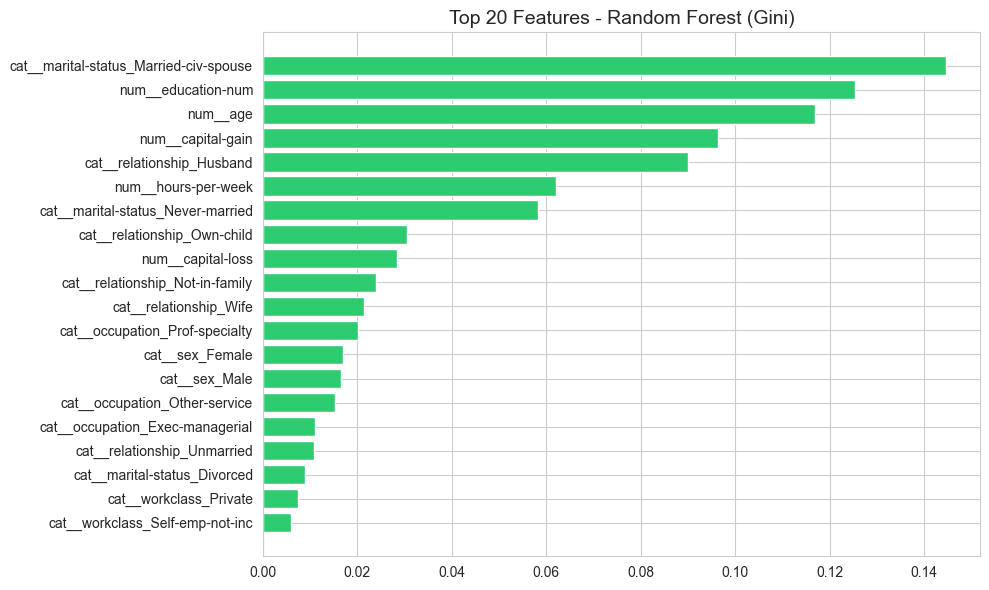

In [7]:

# %%
importances_rf = rf_best.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Features - Random Forest (Gini)", fontsize=14)
plt.barh(range(20), importances_rf[indices_rf], align="center", color='#2ecc71')
plt.yticks(range(20), [feature_names[i] for i in indices_rf], fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()




3. Phase 2: Gradient Boosting (XGBoost)
   
**Goal:** High precision and state-of-the-art performance via boosting

In [8]:
# %%
# Define Hyperparameter Grid
xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'scale_pos_weight': [1, 3]  # 3 ≈ Balanced for this dataset
}

print("Starting XGBoost Tuning...")
# Note: No early_stopping here, strictly tuning
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_random = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_params,
    n_iter=20,
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring='f1'
)

xgb_random.fit(X_train, y_train)
print(f"\nBest XGB Params: {xgb_random.best_params_}")



Starting XGBoost Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best XGB Params: {'subsample': 0.7, 'scale_pos_weight': 3, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


XGB Refinement (Early Stopping)

In [9]:

print("Refining XGBoost with Early Stopping...")
xgb_final = xgb.XGBClassifier(
    **xgb_random.best_params_,
    objective='binary:logistic',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=20  # Stop if val loss doesn't improve
)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Save Model
joblib.dump(xgb_final, '../models/xgb_best.joblib')



Refining XGBoost with Early Stopping...


['../models/xgb_best.joblib']

XGB Evaluation & Learning Curve


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      5574
           1       0.62      0.86      0.72      1753

    accuracy                           0.84      7327
   macro avg       0.78      0.84      0.80      7327
weighted avg       0.87      0.84      0.85      7327



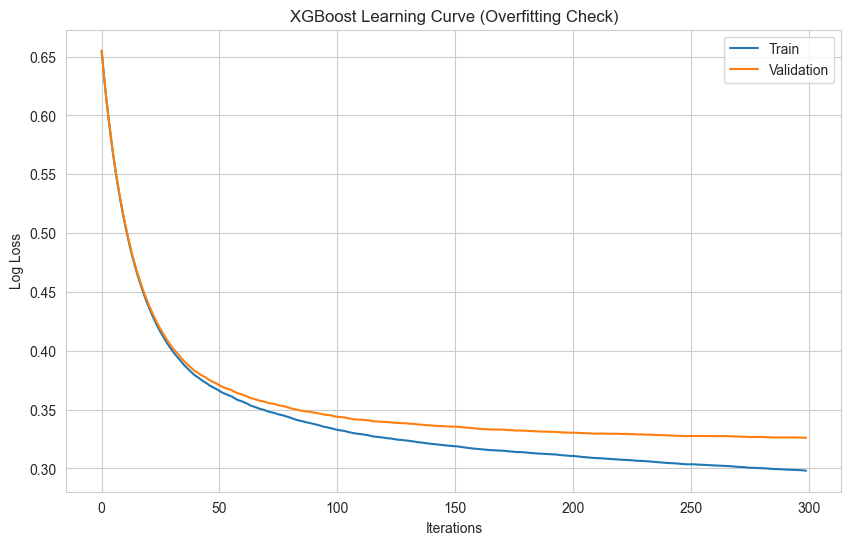

In [10]:
# %%
# Metrics
results = xgb_final.evals_result()
y_pred_xgb = xgb_final.predict(X_val)

print("\nXGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb))

# Learning Curve Plot
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Iterations')
plt.title('XGBoost Learning Curve (Overfitting Check)')
plt.show()



XGB Feature Importance (Gain)

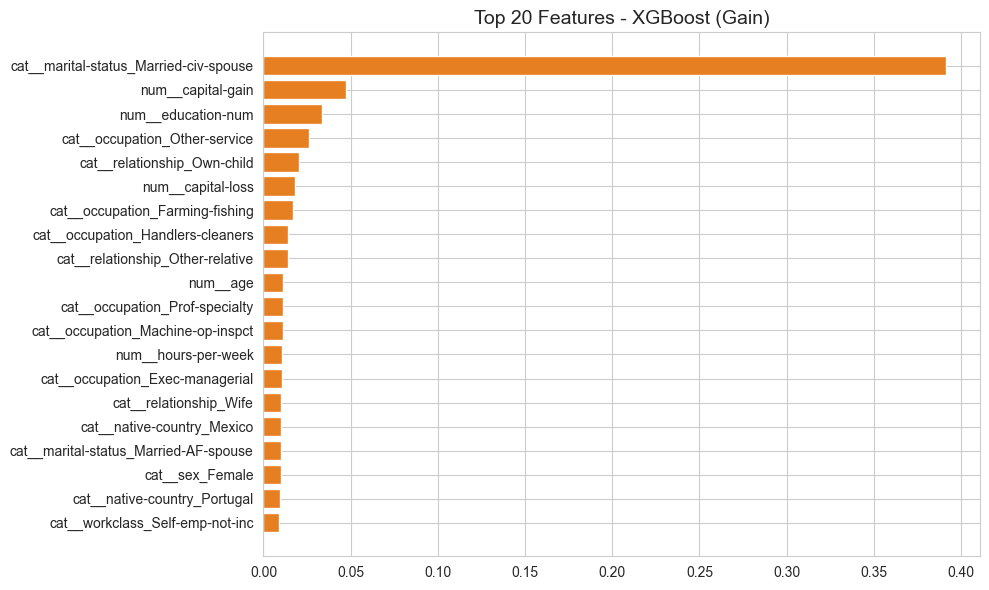

In [11]:


# %%
importances_xgb = xgb_final.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Features - XGBoost (Gain)", fontsize=14)
plt.barh(range(20), importances_xgb[indices_xgb], align="center", color='#e67e22')
plt.yticks(range(20), [feature_names[i] for i in indices_xgb], fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


4. Model Comparison (The "Money Shot")

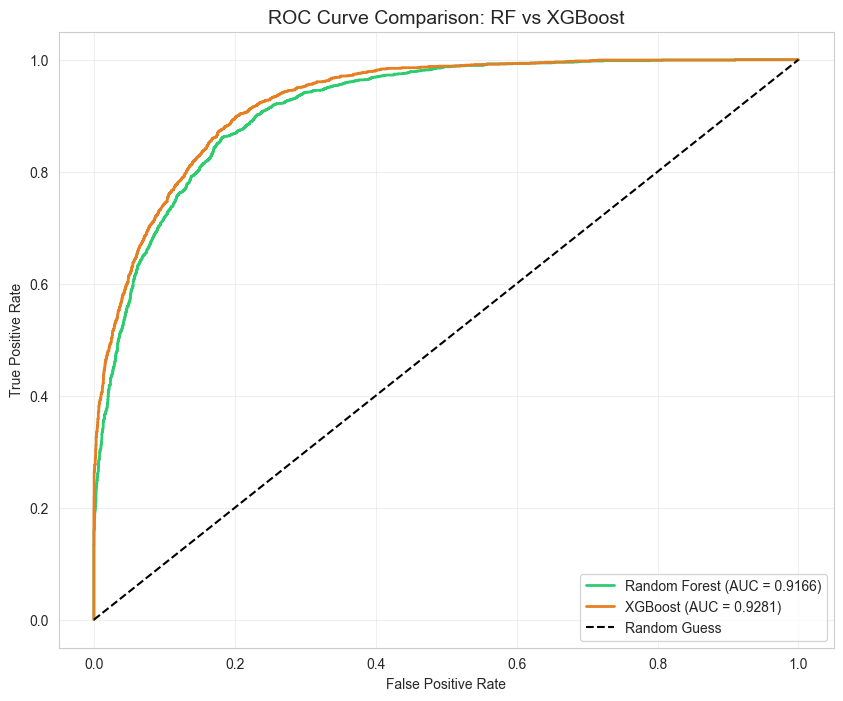

In [12]:
# %%
from sklearn.metrics import roc_curve

# Get Probabilities
y_prob_rf = rf_best.predict_proba(X_val)[:, 1]
y_prob_xgb = xgb_final.predict_proba(X_val)[:, 1]

# Calculate ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_prob_xgb)
auc_rf = roc_auc_score(y_val, y_prob_rf)
auc_xgb = roc_auc_score(y_val, y_prob_xgb)

# Plot Comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', color='#2ecc71', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', color='#e67e22', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: RF vs XGBoost', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()